In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform

DATA_DIR = Path("data")

In [2]:
# Load ND gene sequences and reference sequences
with open(DATA_DIR / "amtdb_nd_seqs.pkl", "rb") as f:
    amtdb_nd_seqs = pickle.load(f)

with open(DATA_DIR / "nd_ref_seqs.pkl", "rb") as f:
    nd_ref_seqs = pickle.load(f)

# Load structural contact data (including res_names for validation)
contact_data = np.load(DATA_DIR / "mito_contact_summary.npz", allow_pickle=True)
GENE_NAME_MAP = {"MT-ND1": "ND1", "MT-ND2": "ND2", "MT-ND3": "ND3",
                 "MT-ND4": "ND4", "MT-ND4L": "ND4L", "MT-ND5": "ND5", "MT-ND6": "ND6"}

mito_contact_summary = {}
for mt_gene, gene in GENE_NAME_MAP.items():
    mito_contact_summary[gene] = {
        "residues": contact_data[f"{mt_gene}_residues"],
        "res_names": contact_data[f"{mt_gene}_res_names"],  # 1-letter AA codes from structure
        "struct_len": len(contact_data[f"{mt_gene}_residues"]),
        "contacts_per_res": contact_data[f"{mt_gene}_contacts_per_res"],
        "downweight": contact_data[f"{mt_gene}_downweight"],
        "intra_per_res": contact_data[f"{mt_gene}_intra_per_res"],
        "inter_mt_per_res": contact_data[f"{mt_gene}_inter_mt_per_res"],
        "inter_nuc_per_res": contact_data[f"{mt_gene}_inter_nuc_per_res"],
    }

# Load sample metadata (dates, locations, haplogroups)
metadata = pd.read_csv(DATA_DIR / "amtdb_meta/amtdb_metadata_linked.csv")
metadata.set_index("sample_id", inplace=True)

# Gene order (genomic position on mtDNA)
GENE_ORDER = ["ND1", "ND2", "ND3", "ND4L", "ND4", "ND5", "ND6"]
sample_ids = list(amtdb_nd_seqs["ND1"].keys())
n_samples = len(sample_ids)

# Summary
print("=" * 70)
print("LOADED DATA SUMMARY")
print("=" * 70)
print(f"Samples: {n_samples}")
print(f"Genes: {len(GENE_ORDER)}")
print(f"Metadata: {len(metadata)} rows")
print(f"\n{'Gene':<6} {'Seq nt':>8} {'Codons':>8} {'Struct':>8} {'Res range':>12} {'Struct seq':>14}")
print("-" * 70)
for gene in GENE_ORDER:
    seq_len = len(nd_ref_seqs[gene])
    n_codons = seq_len // 3
    struct_len = mito_contact_summary[gene]["struct_len"]
    res = mito_contact_summary[gene]["residues"]
    res_names = mito_contact_summary[gene]["res_names"]
    seq_preview = "".join(res_names[:8]) + "..."
    print(f"{gene:<6} {seq_len:>8} {n_codons:>8} {struct_len:>8} {res.min():>5}-{res.max():<5} {seq_preview:>14}")

print(f"\nDate range: {metadata['date_bp'].min():.0f} - {metadata['date_bp'].max():.0f} BP")

LOADED DATA SUMMARY
Samples: 1940
Genes: 7
Metadata: 1374 rows

Gene     Seq nt   Codons   Struct    Res range     Struct seq
----------------------------------------------------------------------
ND1         956      318      316     3-318      MANLLLLI...
ND2        1042      347      347     1-347      MNPLAQPV...
ND3         346      115      115     1-115      MNFALILM...
ND4L        297       99       98     1-98       MPLIYMNI...
ND4        1378      459      459     1-459      MLKLIVPT...
ND5        1812      604      601     3-603      MHTTMTTL...
ND6         525      175      173     1-173      MMYALFLL...

Date range: 200 - 13980 BP


In [3]:
# Step 1: Convert sequences to numeric matrix, selecting only structurally-resolved codons
# - Convert 1-based residue indices to 0-based codon indices
# - Select only codons with structural coverage (×3 for nucleotides)
# - Exclude trailing nucleotides (incomplete stop codons)

NUC_TO_INT = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4}

def seq_to_array(seq):
    """Convert nucleotide sequence to integer array."""
    return np.array([NUC_TO_INT.get(c, 4) for c in seq], dtype=np.int8)

def extract_structural_codons(seq, residue_indices_1based):
    """Extract nucleotides for codons that have structural coverage.
    
    Args:
        seq: Full nucleotide sequence for gene
        residue_indices_1based: 1-based residue indices from structure
    
    Returns:
        Concatenated nucleotides for covered codons only
    """
    # Convert 1-based residue indices to 0-based codon indices
    codon_indices = residue_indices_1based - 1
    
    # Extract 3 nucleotides per codon
    nt_list = []
    for ci in codon_indices:
        start = ci * 3
        end = start + 3
        if end <= len(seq):  # Safety check
            nt_list.append(seq[start:end])
    
    return ''.join(nt_list)

# Build concatenated sequence matrix using only structurally-resolved positions
gene_struct_info = {}
total_struct_len = 0

for gene in GENE_ORDER:
    residues = mito_contact_summary[gene]["residues"]
    n_struct_codons = len(residues)
    n_struct_nt = n_struct_codons * 3
    
    gene_struct_info[gene] = {
        "residues_1based": residues,
        "codon_indices_0based": residues - 1,
        "n_codons": n_struct_codons,
        "n_nt": n_struct_nt,
        "start_pos": total_struct_len,
        "end_pos": total_struct_len + n_struct_nt,
    }
    total_struct_len += n_struct_nt

# Build matrix
seq_matrix = np.zeros((n_samples, total_struct_len), dtype=np.int8)

for gene in GENE_ORDER:
    info = gene_struct_info[gene]
    start, end = info["start_pos"], info["end_pos"]
    residues = info["residues_1based"]
    
    for i, sid in enumerate(sample_ids):
        full_seq = amtdb_nd_seqs[gene][sid]
        struct_seq = extract_structural_codons(full_seq, residues)
        seq_matrix[i, start:end] = seq_to_array(struct_seq)

print(f"Sequence matrix: {seq_matrix.shape} (samples × structurally-resolved positions)")
print(f"Total positions: {total_struct_len} nt ({total_struct_len // 3} codons)")

print(f"\n{'Gene':<6} {'Full nt':>8} {'Full cod':>9} {'Struct cod':>11} {'Struct nt':>10} {'Slice':>14}")
print("-" * 68)
for gene in GENE_ORDER:
    info = gene_struct_info[gene]
    full_len = len(nd_ref_seqs[gene])
    full_codons = full_len // 3
    print(f"{gene:<6} {full_len:>8} {full_codons:>9} {info['n_codons']:>11} {info['n_nt']:>10} {info['start_pos']:>6}-{info['end_pos']:<6}")

Sequence matrix: (1940, 6327) (samples × structurally-resolved positions)
Total positions: 6327 nt (2109 codons)

Gene    Full nt  Full cod  Struct cod  Struct nt          Slice
--------------------------------------------------------------------
ND1         956       318         316        948      0-948   
ND2        1042       347         347       1041    948-1989  
ND3         346       115         115        345   1989-2334  
ND4L        297        99          98        294   2334-2628  
ND4        1378       459         459       1377   2628-4005  
ND5        1812       604         601       1803   4005-5808  
ND6         525       175         173        519   5808-6327  


In [4]:
# Validation: Translate reference codons and compare to structural residue names
# This confirms our index alignment is correct

# Mitochondrial codon table (vertebrate)
MT_CODON_TABLE = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'TGT': 'C', 'TGC': 'C', 'TGA': 'W', 'TGG': 'W',  # TGA=W in mt
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'M', 'ATG': 'M',  # ATA=M in mt
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'AGT': 'S', 'AGC': 'S', 'AGA': '*', 'AGG': '*',  # AGA/AGG=* in mt
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G',
}

def translate_codon(codon):
    """Translate a codon using mitochondrial genetic code."""
    codon = codon.upper()
    if 'N' in codon:
        return 'X'  # Unknown
    return MT_CODON_TABLE.get(codon, 'X')

print("=" * 70)
print("VALIDATION: Reference codon translation vs structural residues")
print("=" * 70)

all_match = True
for gene in GENE_ORDER:
    ref_seq = nd_ref_seqs[gene]
    residues_1based = mito_contact_summary[gene]["residues"]
    struct_aa = mito_contact_summary[gene]["res_names"]
    
    # Translate reference codons at structural positions
    translated = []
    for res_idx in residues_1based:
        codon_idx = res_idx - 1  # Convert to 0-based
        codon_start = codon_idx * 3
        codon = ref_seq[codon_start:codon_start + 3]
        aa = translate_codon(codon)
        translated.append(aa)
    
    translated = np.array(translated)
    struct_aa = np.array(struct_aa)
    
    # Compare
    matches = (translated == struct_aa).sum()
    total = len(translated)
    match_pct = 100 * matches / total
    
    # Show mismatches if any
    mismatches = np.where(translated != struct_aa)[0]
    status = "OK" if matches == total else f"MISMATCH ({len(mismatches)})"
    
    print(f"\n{gene}: {matches}/{total} ({match_pct:.1f}%) - {status}")
    print(f"  Translated: {''.join(translated[:20])}...")
    print(f"  Structure:  {''.join(struct_aa[:20])}...")
    
    if len(mismatches) > 0 and len(mismatches) <= 5:
        print(f"  Mismatches at positions: {mismatches}")
        for i in mismatches:
            print(f"    pos {residues_1based[i]}: translated={translated[i]}, struct={struct_aa[i]}")
        all_match = False

print(f"\n{'=' * 70}")
print(f"Overall: {'ALL GENES MATCH' if all_match else 'SOME MISMATCHES - CHECK ALIGNMENT'}")
print(f"{'=' * 70}")

VALIDATION: Reference codon translation vs structural residues

ND1: 316/316 (100.0%) - OK
  Translated: MANLLLLIVPILIAMAFLML...
  Structure:  MANLLLLIVPILIAMAFLML...

ND2: 346/347 (99.7%) - MISMATCH (1)
  Translated: INPLAQPVIYSTIFAGTLIT...
  Structure:  MNPLAQPVIYSTIFAGTLIT...
  Mismatches at positions: [0]
    pos 1: translated=I, struct=M

ND3: 115/115 (100.0%) - OK
  Translated: MNFALILMINTLLALLLMII...
  Structure:  MNFALILMINTLLALLLMII...

ND4L: 98/98 (100.0%) - OK
  Translated: MPLIYMNIMLAFTISLLGML...
  Structure:  MPLIYMNIMLAFTISLLGML...

ND4: 459/459 (100.0%) - OK
  Translated: MLKLIVPTIMLLPLTWLSKK...
  Structure:  MLKLIVPTIMLLPLTWLSKK...

ND5: 601/601 (100.0%) - OK
  Translated: MHTTMTTLTLTSLIPPILTT...
  Structure:  MHTTMTTLTLTSLIPPILTT...

ND6: 173/173 (100.0%) - OK
  Translated: MMYALFLLSVGLVMGFVGFS...
  Structure:  MMYALFLLSVGLVMGFVGFS...

Overall: SOME MISMATCHES - CHECK ALIGNMENT


In [5]:
# Validation: Translate ancient sample codons and compare to structural residues
# Quantify amino acid similarity across all 1374 samples

def translate_seq_at_positions(nt_seq, residue_indices_1based):
    """Translate codons at specified positions using mitochondrial genetic code."""
    aa_list = []
    for res_idx in residue_indices_1based:
        codon_idx = res_idx - 1  # Convert to 0-based
        codon_start = codon_idx * 3
        codon = nt_seq[codon_start:codon_start + 3]
        aa = translate_codon(codon)
        aa_list.append(aa)
    return ''.join(aa_list)

print("=" * 70)
print("VALIDATION: Ancient sample translations vs structural residues")
print("=" * 70)

# For each gene, translate all samples and compute similarity to structure
sample_aa_similarity = {gene: [] for gene in GENE_ORDER}
sample_aa_sequences = {gene: {} for gene in GENE_ORDER}  # Store for later analysis

for gene in GENE_ORDER:
    residues_1based = mito_contact_summary[gene]["residues"]
    struct_aa = np.array(list(mito_contact_summary[gene]["res_names"]))
    n_positions = len(struct_aa)
    
    for sid in sample_ids:
        nt_seq = amtdb_nd_seqs[gene][sid]
        sample_aa = translate_seq_at_positions(nt_seq, residues_1based)
        sample_aa_arr = np.array(list(sample_aa))
        
        # Store translated sequence
        sample_aa_sequences[gene][sid] = sample_aa
        
        # Count matches (excluding X from unknown codons)
        valid_mask = sample_aa_arr != 'X'
        if valid_mask.sum() > 0:
            matches = (sample_aa_arr[valid_mask] == struct_aa[valid_mask]).sum()
            similarity = matches / valid_mask.sum()
        else:
            similarity = 0.0
        sample_aa_similarity[gene].append(similarity)

# Summary statistics per gene
print(f"\n{'Gene':<6} {'Positions':>10} {'Mean sim':>10} {'Min':>8} {'Max':>8} {'<95%':>8} {'<90%':>8}")
print("-" * 68)

for gene in GENE_ORDER:
    sims = np.array(sample_aa_similarity[gene])
    n_pos = len(mito_contact_summary[gene]["residues"])
    mean_sim = sims.mean()
    min_sim = sims.min()
    max_sim = sims.max()
    below_95 = (sims < 0.95).sum()
    below_90 = (sims < 0.90).sum()
    print(f"{gene:<6} {n_pos:>10} {mean_sim:>10.4f} {min_sim:>8.4f} {max_sim:>8.4f} {below_95:>8} {below_90:>8}")

# Overall statistics
all_sims = np.concatenate([sample_aa_similarity[g] for g in GENE_ORDER])
print(f"\n{'TOTAL':<6} {'-':>10} {all_sims.mean():>10.4f} {all_sims.min():>8.4f} {all_sims.max():>8.4f}")

# Identify samples with lowest similarity (potential alignment issues or divergent sequences)
print(f"\n" + "=" * 70)
print("Samples with lowest average similarity to structure:")
print("=" * 70)

# Compute per-sample average across genes
sample_avg_sim = {}
for sid in sample_ids:
    avg = np.mean([sample_aa_similarity[gene][sample_ids.index(sid)] for gene in GENE_ORDER])
    sample_avg_sim[sid] = avg

# Sort and show bottom 10
sorted_samples = sorted(sample_avg_sim.items(), key=lambda x: x[1])
print(f"\n{'Sample':<15} {'Avg sim':>10} {'ND1':>8} {'ND2':>8} {'ND3':>8} {'ND4L':>8} {'ND4':>8} {'ND5':>8} {'ND6':>8}")
print("-" * 95)
for sid, avg in sorted_samples[:10]:
    idx = sample_ids.index(sid)
    gene_sims = [f"{sample_aa_similarity[g][idx]:.4f}" for g in GENE_ORDER]
    print(f"{sid:<15} {avg:>10.4f} {' '.join(f'{s:>8}' for s in gene_sims)}")

VALIDATION: Ancient sample translations vs structural residues

Gene    Positions   Mean sim      Min      Max     <95%     <90%
--------------------------------------------------------------------
ND1           316     0.9981   0.0601   1.0000        2        2
ND2           347     0.9955   0.0778   1.0000        2        2
ND3           115     0.9966   0.1130   1.0000        2        2
ND4L           98     0.9981   0.0000   1.0000        4        3
ND4           459     0.9988   0.0763   1.0000        2        2
ND5           601     0.9982   0.0732   1.0000        2        2
ND6           173     0.9987   0.1098   1.0000        2        2

TOTAL           -     0.9977   0.0000   1.0000

Samples with lowest average similarity to structure:

Sample             Avg sim      ND1      ND2      ND3     ND4L      ND4      ND5      ND6
-----------------------------------------------------------------------------------------------
MX150               0.0761   0.0601   0.0778   0.1130   0.

In [6]:
# Flag problematic samples in metadata based on AA similarity analysis
# Issues detected:
#   - MX150, SX30: +1 frameshift (all genes show ~6-10% similarity)
#   - I2629: Excessive missing data (ND4L is 100% Ns)

# Compute per-sample statistics for flagging
FRAMESHIFT_THRESHOLD = 0.50  # Samples with avg similarity < 50% likely have frameshift
HIGH_MISSING_THRESHOLD = 0.80  # Flag if any gene has >80% Ns

sample_qc = []
for sid in sample_ids:
    idx = sample_ids.index(sid)
    
    # Average AA similarity across genes
    avg_sim = np.mean([sample_aa_similarity[gene][idx] for gene in GENE_ORDER])
    min_sim = min([sample_aa_similarity[gene][idx] for gene in GENE_ORDER])
    
    # Count N fraction per gene (missing data)
    n_fractions = []
    for gene in GENE_ORDER:
        seq = amtdb_nd_seqs[gene][sid]
        n_frac = seq.count('N') / len(seq)
        n_fractions.append(n_frac)
    max_n_frac = max(n_fractions)
    
    # Determine flags
    flags = []
    if avg_sim < FRAMESHIFT_THRESHOLD:
        flags.append("frameshift")
    if max_n_frac > HIGH_MISSING_THRESHOLD:
        flags.append("high_missing")
    if min_sim == 0.0:
        flags.append("zero_similarity")
    
    sample_qc.append({
        "sample_id": sid,
        "avg_aa_similarity": avg_sim,
        "min_aa_similarity": min_sim,
        "max_n_fraction": max_n_frac,
        "qc_flags": "|".join(flags) if flags else "",
        "qc_pass": len(flags) == 0,
    })

qc_df = pd.DataFrame(sample_qc).set_index("sample_id")

# Add QC columns to metadata
metadata["avg_aa_similarity"] = qc_df["avg_aa_similarity"]
metadata["min_aa_similarity"] = qc_df["min_aa_similarity"]
metadata["max_n_fraction"] = qc_df["max_n_fraction"]
metadata["qc_flags"] = qc_df["qc_flags"]
metadata["qc_pass"] = qc_df["qc_pass"]

# Summary
n_flagged = (~metadata["qc_pass"]).sum()
n_pass = metadata["qc_pass"].sum()

print("=" * 70)
print("SAMPLE QC SUMMARY")
print("=" * 70)
print(f"Total samples: {len(metadata)}")
print(f"QC pass: {n_pass}")
print(f"QC flagged: {n_flagged}")

print(f"\nFlagged samples:")
print("-" * 70)
flagged = metadata[~metadata["qc_pass"]].copy()
flagged_display = flagged[["avg_aa_similarity", "min_aa_similarity", "max_n_fraction", "qc_flags"]]
print(flagged_display.to_string())

print(f"\n" + "=" * 70)
print("Recommendation: Exclude flagged samples from phylogenetic analysis")
print("=" * 70)

SAMPLE QC SUMMARY
Total samples: 1374
QC pass: 1365
QC flagged: 9

Flagged samples:
----------------------------------------------------------------------
           avg_aa_similarity  min_aa_similarity  max_n_fraction                      qc_flags
sample_id                                                                                    
DA145               0.999300           0.995098        0.895393                  high_missing
DA188               0.990991           0.968750        0.902111                  high_missing
DA48                1.000000           1.000000        0.867562                  high_missing
I2629               0.852277           0.000000        1.000000  high_missing|zero_similarity
I5473               1.000000           1.000000        0.947977                  high_missing
I7639               1.000000           1.000000        0.907514                  high_missing
MX150               0.076122           0.020408        0.000000                    frameshift

In [7]:
# Filter samples to only those passing QC
# This ensures all downstream objects are aligned

# Get passing sample IDs (preserving order from original sample_ids)
qc_pass_mask = np.array([metadata.loc[sid, "qc_pass"] if sid in metadata.index else False
                          for sid in sample_ids])

sample_ids_qc = [sid for sid, passed in zip(sample_ids, qc_pass_mask) if passed]
n_samples_qc = len(sample_ids_qc)

# Filter sequence matrix (rows correspond to samples)
seq_matrix_qc = seq_matrix[qc_pass_mask]

# Filter metadata to passing samples only (for convenience)
metadata_qc = metadata[metadata["qc_pass"]].copy()

# Verify alignment
print("=" * 70)
print("QC FILTERING SUMMARY")
print("=" * 70)
print(f"Original samples: {len(sample_ids)}")
print(f"Passing QC: {n_samples_qc}")
print(f"Excluded: {len(sample_ids) - n_samples_qc}")

print(f"\nFiltered objects:")
print(f"  sample_ids_qc: {len(sample_ids_qc)} samples")
print(f"  seq_matrix_qc: {seq_matrix_qc.shape}")
print(f"  metadata_qc: {len(metadata_qc)} rows")

# Verify index alignment
alignment_check = all(sid in metadata_qc.index for sid in sample_ids_qc)
print(f"\nIndex alignment check: {'PASS' if alignment_check else 'FAIL'}")

# Show excluded samples
print(f"\nExcluded samples:")
for sid in sample_ids:
    if sid not in sample_ids_qc:
        flags = metadata.loc[sid, "qc_flags"] if sid in metadata.index else "unknown"
        print(f"  {sid}: {flags}")

QC FILTERING SUMMARY
Original samples: 1940
Passing QC: 1365
Excluded: 575

Filtered objects:
  sample_ids_qc: 1365 samples
  seq_matrix_qc: (1365, 6327)
  metadata_qc: 1365 rows

Index alignment check: PASS

Excluded samples:
  DA145: high_missing
  DA188: high_missing
  DA48: high_missing
  I2629: high_missing|zero_similarity
  I5473: high_missing
  I7639: high_missing
  MX150: frameshift
  PCA0032: high_missing
  SX30: frameshift
  19727: unknown
  20351: unknown
  20374: unknown
  30900: unknown
  ATP16: unknown
  ATP2: unknown
  ATP9: unknown
  Aes1: unknown
  Aes10: unknown
  Aes14: unknown
  Aes15: unknown
  Aes18: unknown
  Aes2: unknown
  Aes21: unknown
  Aes4: unknown
  Aes5: unknown
  Aes6: unknown
  Aes8: unknown
  Aes9: unknown
  Ampack_1: unknown
  BerryAuBac1: unknown
  COV20126: unknown
  DV16: unknown
  Denisova3: unknown
  Falkenstein: unknown
  GOK2: unknown
  GOK4: unknown
  GOK5: unknown
  GoyetQ116-1: unknown
  HUGO_167: unknown
  HUGO_168: unknown
  HUGO_169sk1: 

In [8]:
# Step 2: Build weight vector aligned with structurally-resolved positions
# Since we only kept codons with structural coverage, weights map 1:1
# Each residue downweight expands to 3 nucleotide positions

weight_vector = np.zeros(total_struct_len, dtype=np.float32)

for gene in GENE_ORDER:
    info = gene_struct_info[gene]
    start, end = info["start_pos"], info["end_pos"]
    downweights = mito_contact_summary[gene]["downweight"]
    
    # Expand: each residue weight → 3 nucleotide positions
    # Since we selected only structural codons, lengths should match exactly
    assert len(downweights) == info["n_codons"], f"{gene}: weight/codon mismatch"
    
    nt_weights = np.repeat(downweights, 3)
    weight_vector[start:end] = nt_weights

# Verify alignment
print(f"Weight vector: {weight_vector.shape}")
print(f"Sequence matrix: {seq_matrix.shape}")
assert len(weight_vector) == seq_matrix.shape[1], "Weight/sequence length mismatch!"

print(f"\nWeight statistics:")
print(f"  Range: {weight_vector.min():.4f} - {weight_vector.max():.4f}")
print(f"  Mean:  {weight_vector.mean():.4f}")
print(f"  Positions with weight=1.0 (default): {(weight_vector == 1.0).sum()}")

print(f"\n{'Gene':<6} {'Positions':>10} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 46)
for gene in GENE_ORDER:
    info = gene_struct_info[gene]
    start, end = info["start_pos"], info["end_pos"]
    w = weight_vector[start:end]
    print(f"{gene:<6} {len(w):>10} {w.min():>8.4f} {w.max():>8.4f} {w.mean():>8.4f}")

Weight vector: (6327,)
Sequence matrix: (1940, 6327)

Weight statistics:
  Range: 0.0588 - 0.3333
  Mean:  0.1008
  Positions with weight=1.0 (default): 0

Gene    Positions      Min      Max     Mean
----------------------------------------------
ND1           948   0.0588   0.2500   0.0956
ND2          1041   0.0588   0.2500   0.0982
ND3           345   0.0625   0.3333   0.1146
ND4L          294   0.0667   0.1429   0.0979
ND4          1377   0.0625   0.2000   0.1000
ND5          1803   0.0588   0.2500   0.1017
ND6           519   0.0625   0.3333   0.1071


# ANALYSIS

In [9]:
# Step 3: Compute pairwise distance matrices (using QC-filtered samples)
# Unweighted: Hamming distance (count of mismatches)
# Weighted: Sum of weights at mismatch positions

def hamming_distance_unweighted(seq_matrix):
    """Compute pairwise Hamming distances (unweighted)."""
    n = seq_matrix.shape[0]
    dist = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            d = np.sum(seq_matrix[i] != seq_matrix[j])
            dist[i, j] = dist[j, i] = d
    return dist

def hamming_distance_weighted(seq_matrix, weights):
    """Compute weighted Hamming distances."""
    n = seq_matrix.shape[0]
    dist = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            mismatches = seq_matrix[i] != seq_matrix[j]
            d = np.sum(weights * mismatches)
            dist[i, j] = dist[j, i] = d
    return dist

print("Computing distance matrices (QC-filtered samples)...")
print(f"  Matrix size: {n_samples_qc} × {n_samples_qc} = {n_samples_qc**2:,} pairs")

import time
t0 = time.time()
dist_unweighted = hamming_distance_unweighted(seq_matrix_qc)
t1 = time.time()
print(f"  Unweighted: {t1-t0:.2f}s")

dist_weighted = hamming_distance_weighted(seq_matrix_qc, weight_vector)
t2 = time.time()
print(f"  Weighted: {t2-t1:.2f}s")

# Summary statistics
print(f"\nDistance statistics:")
print(f"{'Metric':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Median':>10}")
print("-" * 54)

# Extract upper triangle (excluding diagonal)
triu_idx = np.triu_indices(n_samples_qc, k=1)
uw_vals = dist_unweighted[triu_idx]
w_vals = dist_weighted[triu_idx]

print(f"{'Unweighted':<12} {uw_vals.min():>10.1f} {uw_vals.max():>10.1f} {uw_vals.mean():>10.1f} {np.median(uw_vals):>10.1f}")
print(f"{'Weighted':<12} {w_vals.min():>10.2f} {w_vals.max():>10.2f} {w_vals.mean():>10.2f} {np.median(w_vals):>10.2f}")

Computing distance matrices (QC-filtered samples)...
  Matrix size: 1365 × 1365 = 1,863,225 pairs
  Unweighted: 4.30s
  Weighted: 6.47s

Distance statistics:
Metric              Min        Max       Mean     Median
------------------------------------------------------
Unweighted          0.0     3724.0      302.4       18.0
Weighted           0.00     383.86      29.75       1.88


In [10]:
# Step 4: Build UPGMA trees via hierarchical clustering (using QC-filtered samples)

# Convert distance matrices to condensed form for scipy
dist_uw_condensed = squareform(dist_unweighted)
dist_w_condensed = squareform(dist_weighted)

# UPGMA clustering (method='average')
print(f"Building UPGMA trees ({n_samples_qc} samples)...")
t0 = time.time()
linkage_unweighted = linkage(dist_uw_condensed, method='average')
t1 = time.time()
print(f"  Unweighted UPGMA: {t1-t0:.2f}s")

linkage_weighted = linkage(dist_w_condensed, method='average')
t2 = time.time()
print(f"  Weighted UPGMA: {t2-t1:.2f}s")

print(f"\nLinkage matrix shape: {linkage_unweighted.shape}")
print(f"  (n_merges × 4: [cluster1, cluster2, distance, n_members])")

Building UPGMA trees (1365 samples)...
  Unweighted UPGMA: 0.03s
  Weighted UPGMA: 0.01s

Linkage matrix shape: (1364, 4)
  (n_merges × 4: [cluster1, cluster2, distance, n_members])


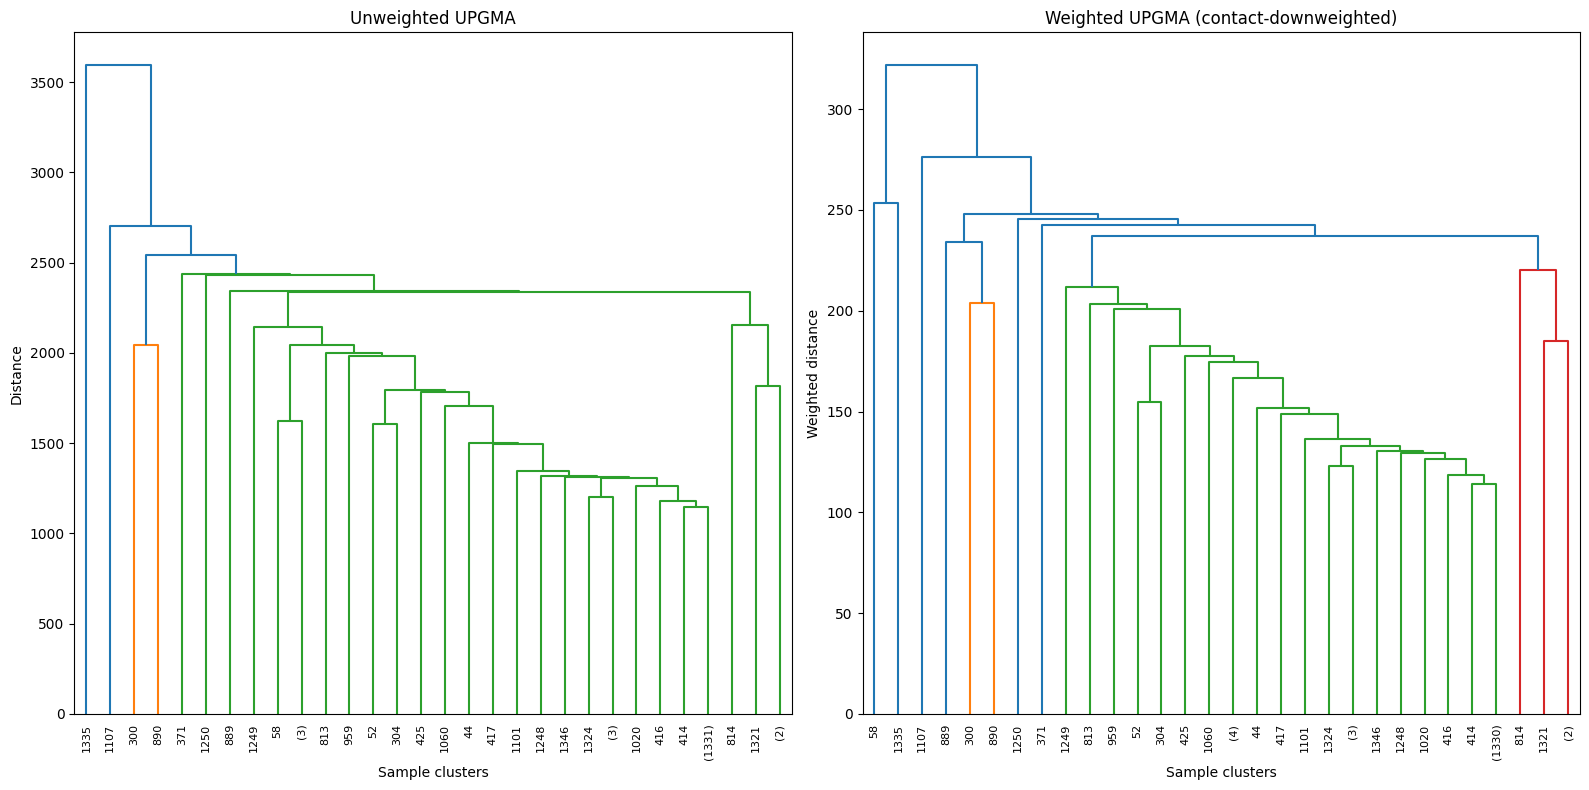

In [11]:
# Visualize: Dendrogram comparison (truncated for readability)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Unweighted tree
ax = axes[0]
dendrogram(linkage_unweighted, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_leaf_counts=True)
ax.set_title(f"Unweighted UPGMA")
ax.set_xlabel("Sample clusters")
ax.set_ylabel("Distance")

# Weighted tree
ax = axes[1]
dendrogram(linkage_weighted, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8, show_leaf_counts=True)
ax.set_title(f"Weighted UPGMA (contact-downweighted)")
ax.set_xlabel("Sample clusters")
ax.set_ylabel("Weighted distance")

plt.tight_layout()
plt.show()

# Serial-Sample WPGMA


... checkpoint ...